# Exercise C++ input/output

In this exercise, C++ input and output streams are used to read numbers and write a table containing the numbers together with their sine and cosine values.

The exercise is split into three parts:

1. Reading numbers from command-line arguments.
2. Reading numbers from the standard input stream.
3. Reading numbers from a file and writing the result to another file.

The program prints a table with columns

$$
x, \sin(x), \cos(x).
$$

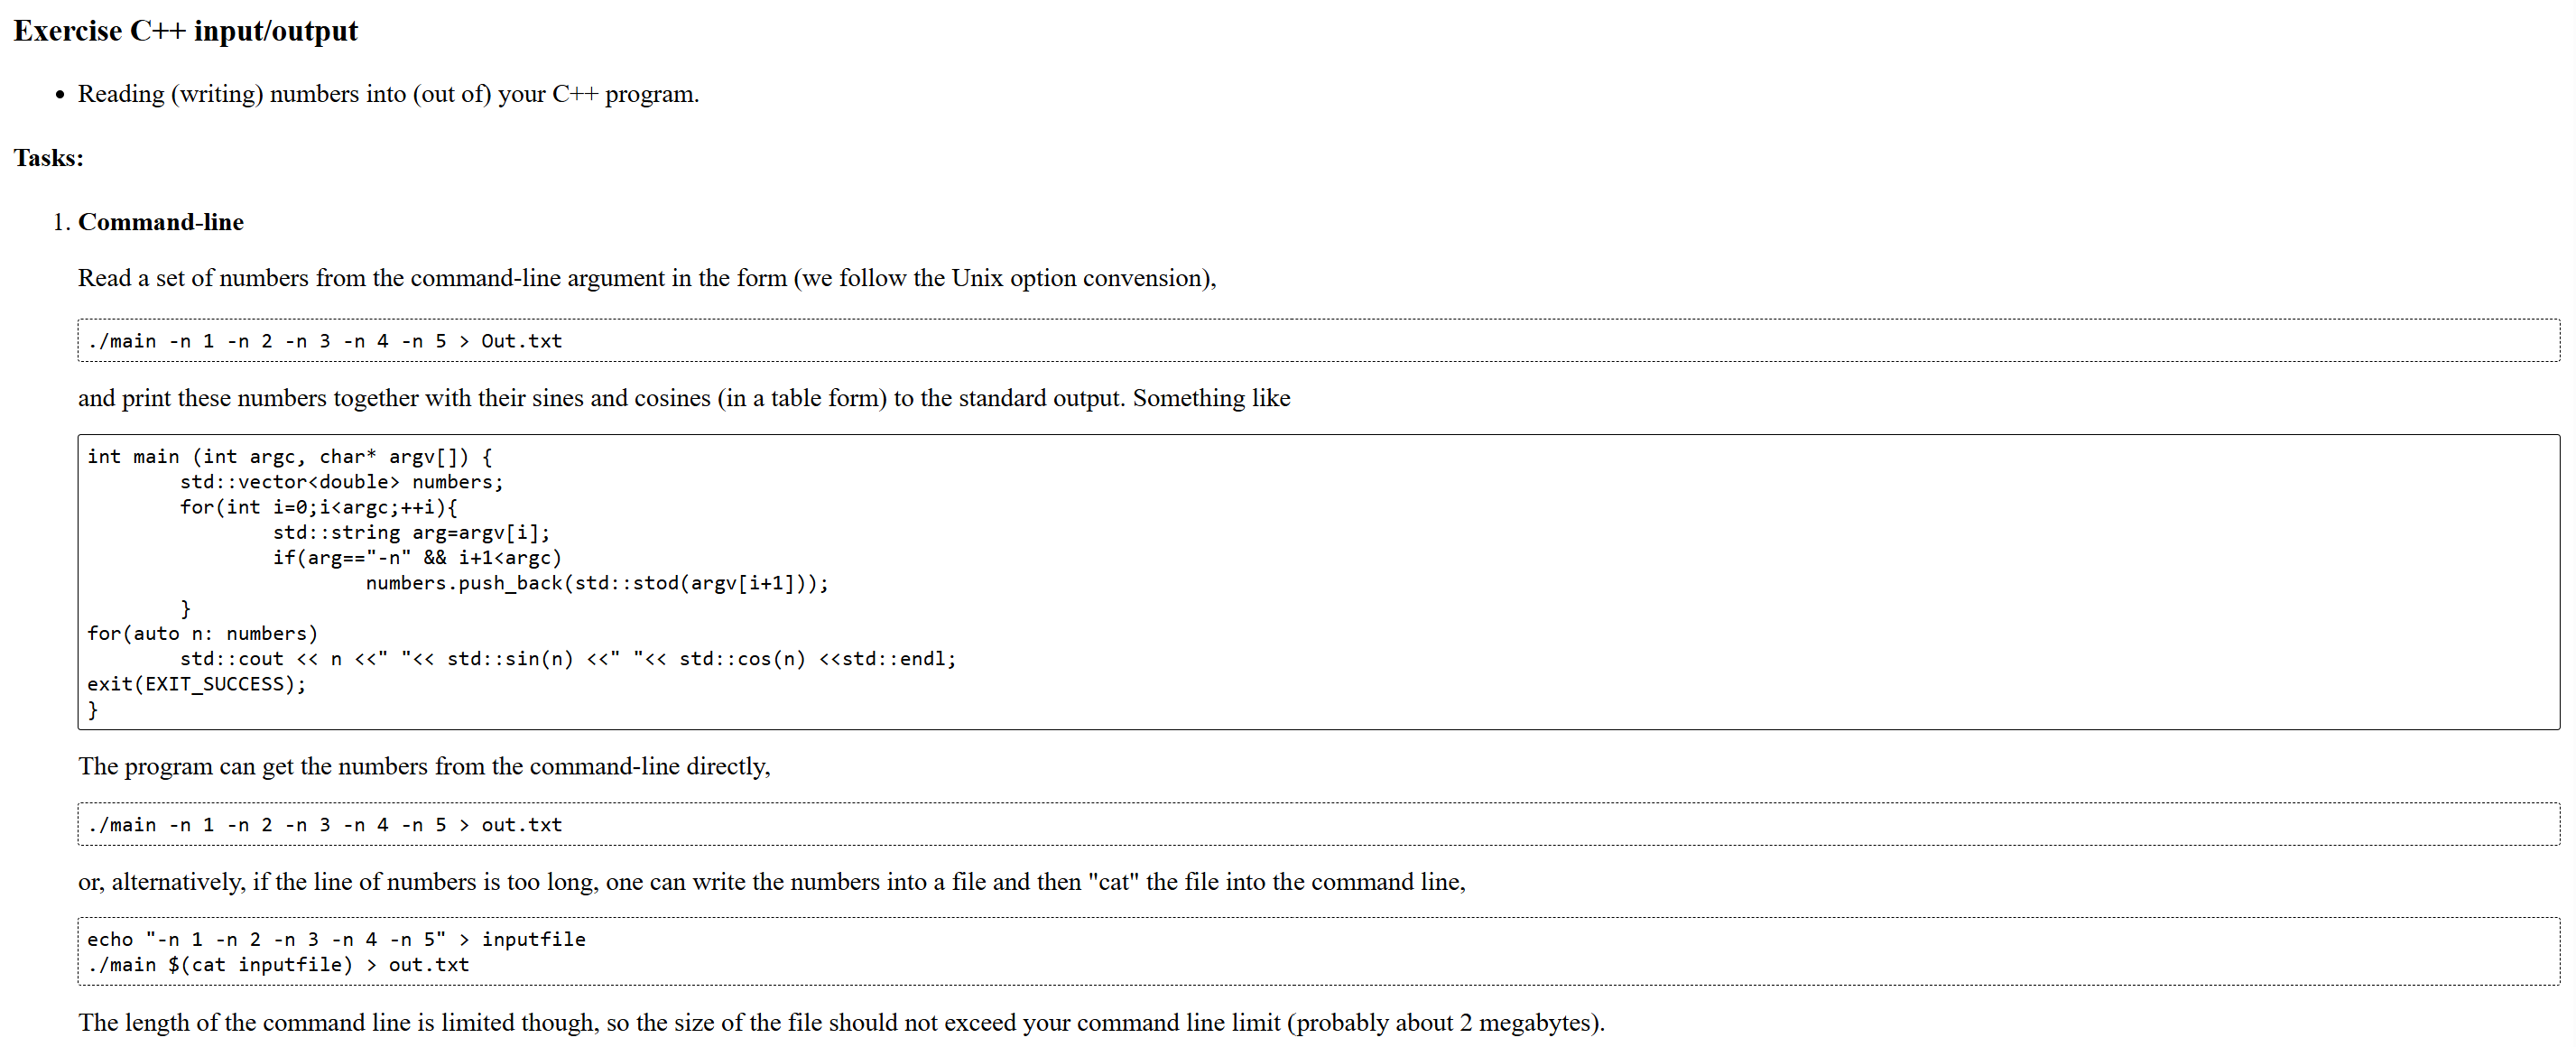

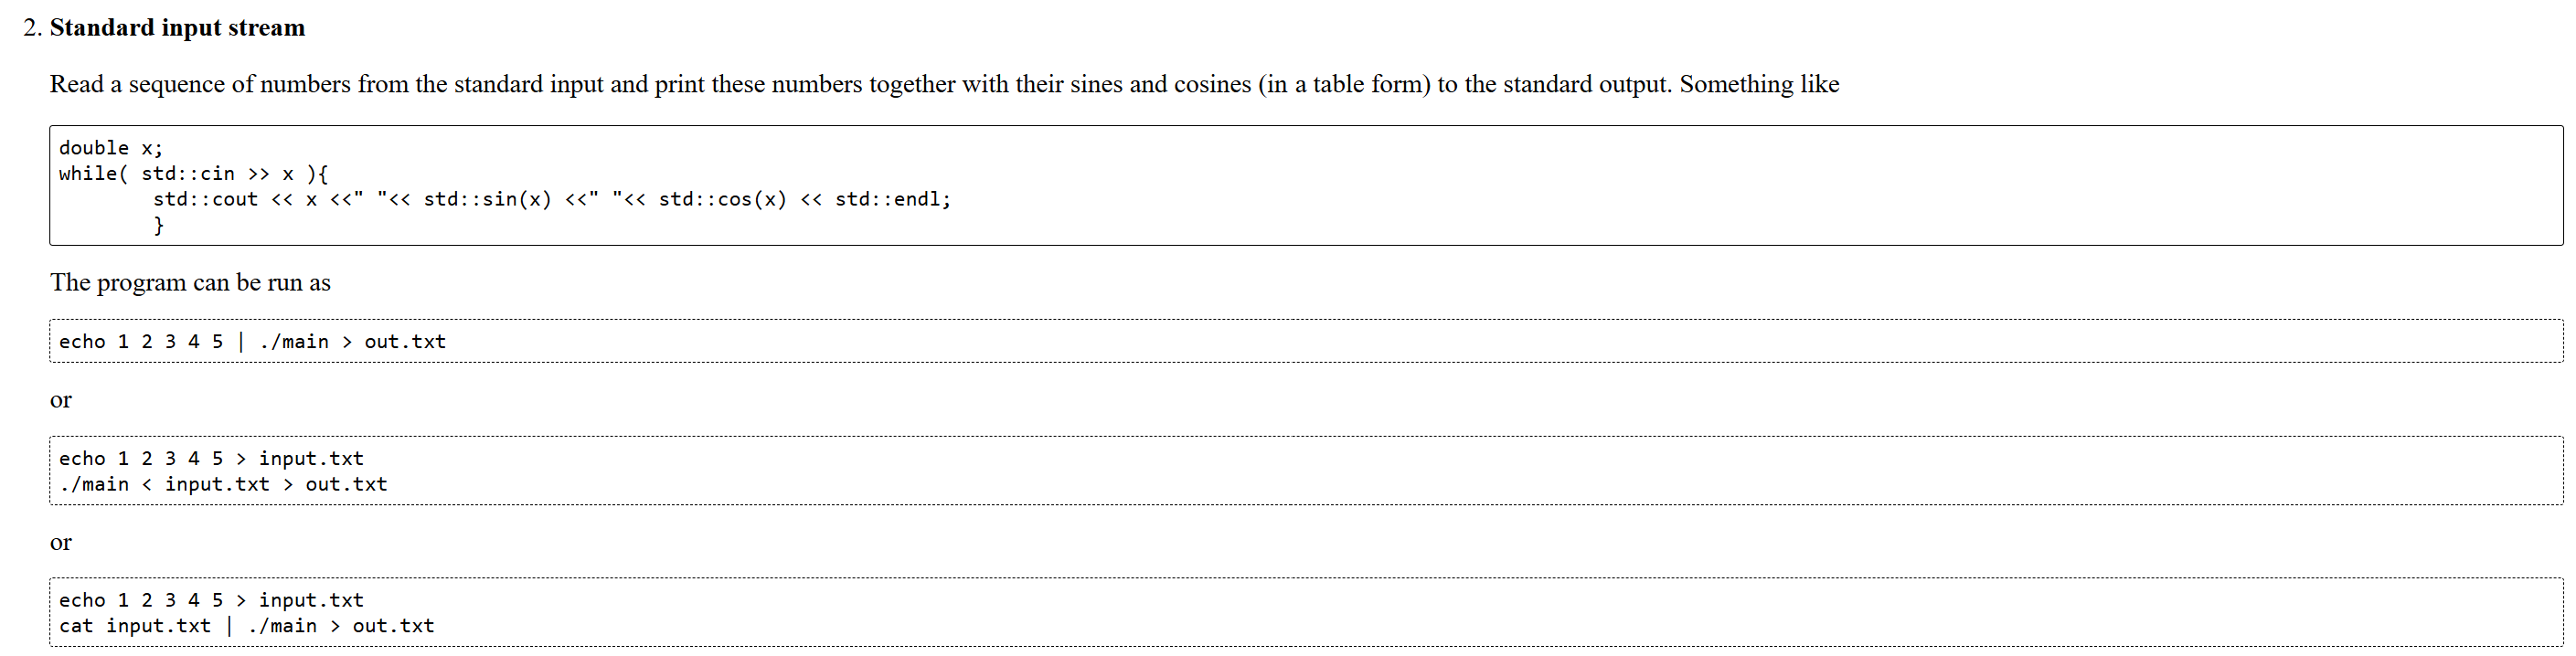

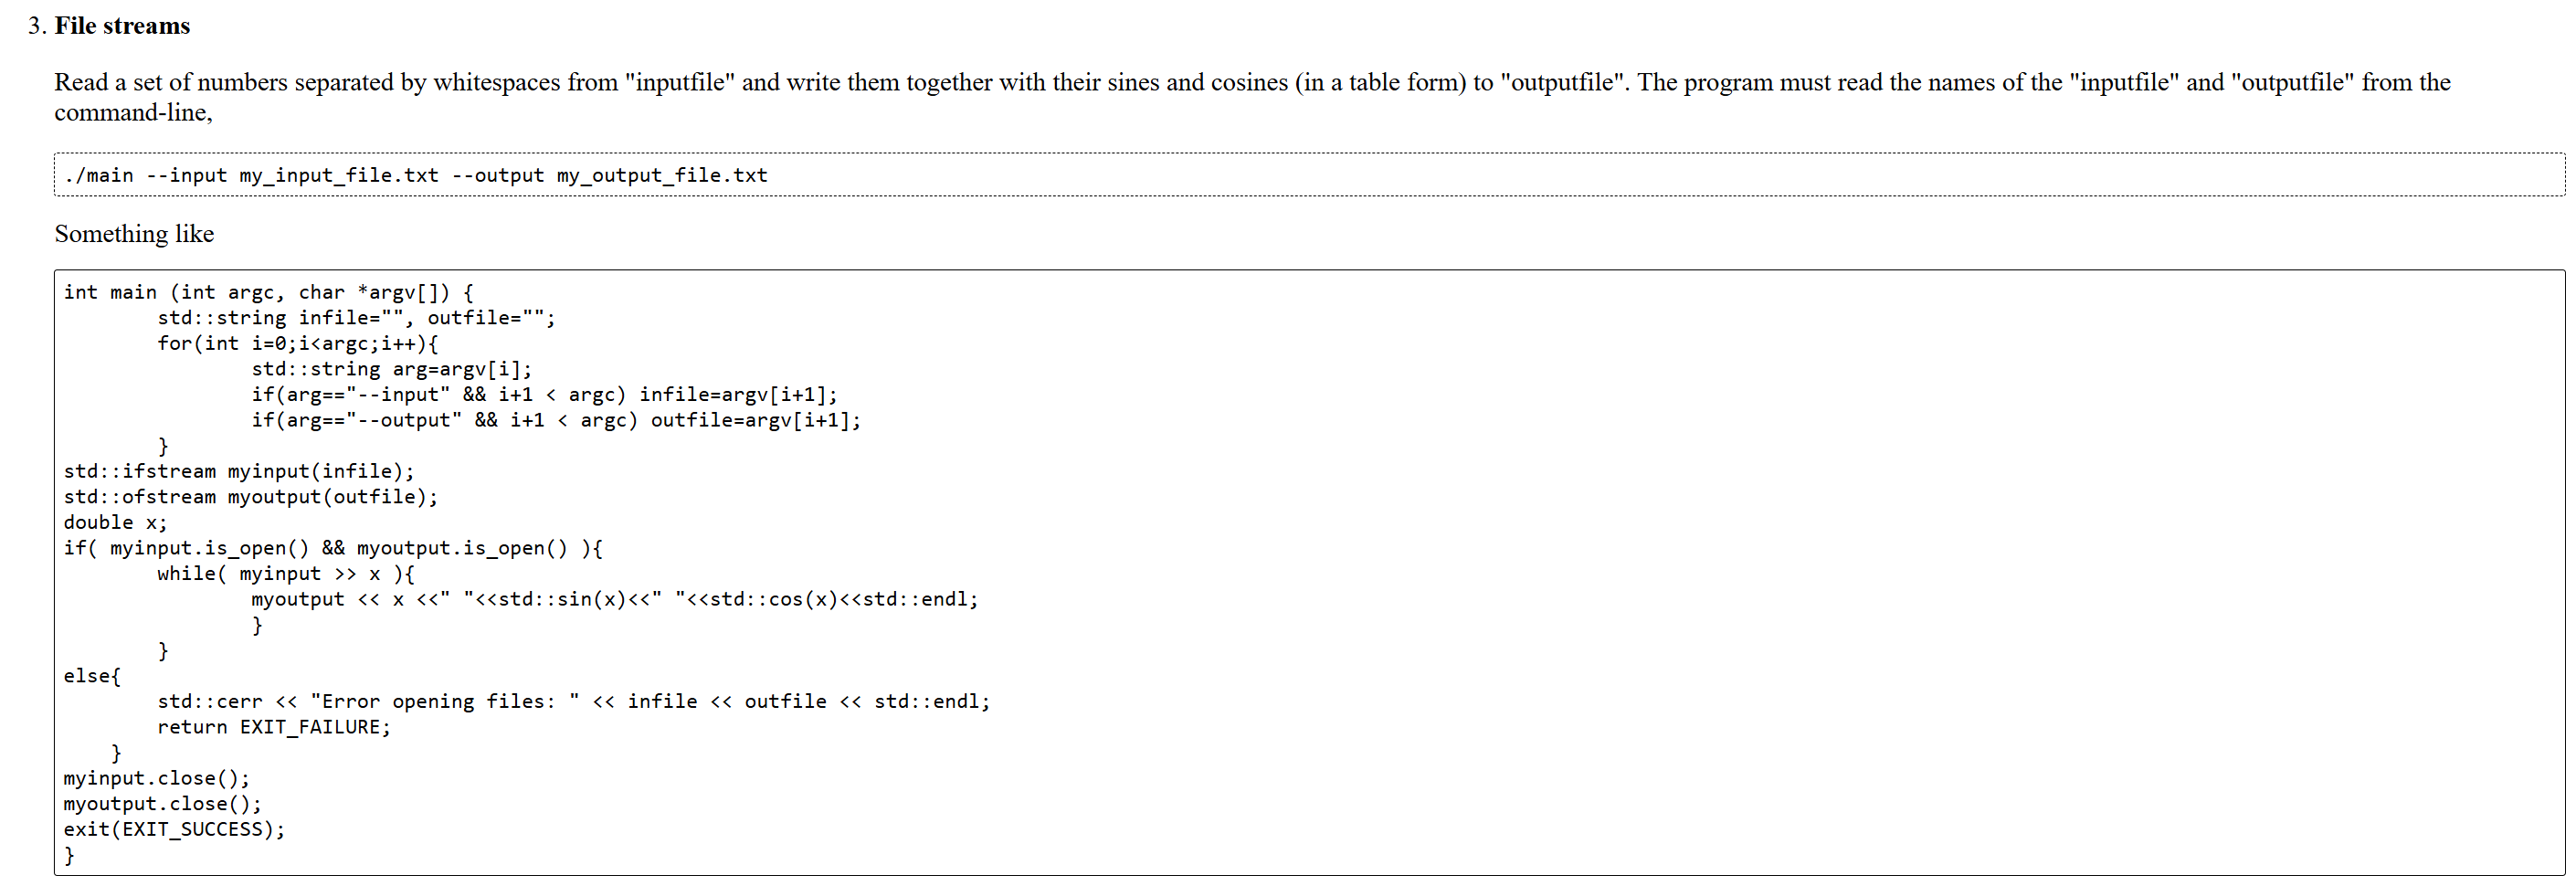

In [ ]:
from pathlib import Path

Path("input_output.cc").write_text(r'''
#include <cmath>
#include <cstdlib>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <string>
#include <vector>

void print_header(std::ostream& out) {
    out << std::setw(15) << "x"
        << std::setw(20) << "sin(x)"
        << std::setw(20) << "cos(x)"
        << "\n";
}

void print_row(std::ostream& out, double x) {
    out << std::setw(15) << x
        << std::setw(20) << std::sin(x)
        << std::setw(20) << std::cos(x)
        << "\n";
}

void write_table(const std::vector<double>& numbers, std::ostream& out) {
    out << std::setprecision(12);
    print_header(out);

    for (double x : numbers) {
        print_row(out, x);
    }
}

void write_table(std::istream& in, std::ostream& out) {
    out << std::setprecision(12);
    print_header(out);

    double x;
    while (in >> x) {
        print_row(out, x);
    }
}

int main(int argc, char* argv[]) {
    std::vector<double> numbers;

    std::string input_file = "";
    std::string output_file = "";

    for (int i = 1; i < argc; ++i) {
        std::string arg = argv[i];

        if (arg == "-n" && i + 1 < argc) {
            numbers.push_back(std::stod(argv[++i]));
        }

        else if (arg == "--input" && i + 1 < argc) {
            input_file = argv[++i];
        }

        else if (arg == "--output" && i + 1 < argc) {
            output_file = argv[++i];
        }
    }

    // Part 3: file streams
    if (!input_file.empty() || !output_file.empty()) {
        if (input_file.empty() || output_file.empty()) {
            std::cerr << "Error: both --input and --output must be given\n";
            return EXIT_FAILURE;
        }

        std::ifstream in(input_file);
        std::ofstream out(output_file);

        if (!in.is_open()) {
            std::cerr << "Error: could not open input file: " << input_file << "\n";
            return EXIT_FAILURE;
        }

        if (!out.is_open()) {
            std::cerr << "Error: could not open output file: " << output_file << "\n";
            return EXIT_FAILURE;
        }

        write_table(in, out);

        return EXIT_SUCCESS;
    }

    // Part 1: command-line numbers
    if (!numbers.empty()) {
        write_table(numbers, std::cout);
        return EXIT_SUCCESS;
    }

    // Part 2: standard input stream
    write_table(std::cin, std::cout);

    return EXIT_SUCCESS;
}
''')

print("Wrote input_output.cc")

In [ ]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "input_output.cc",
    "-o",
    "input_output"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    print("Compilation successful.")
else:
    print("Compilation failed.")

In [ ]:
import subprocess
from pathlib import Path

run = subprocess.run(
    ["./input_output", "-n", "1", "-n", "2", "-n", "3", "-n", "4", "-n", "5"],
    text=True,
    capture_output=True
)

Path("Out_commandline.txt").write_text(run.stdout + run.stderr)

print("Program output:")
print(run.stdout)
print(run.stderr)
print("Wrote Out_commandline.txt")

In [ ]:
import subprocess
from pathlib import Path

input_numbers = "1 2 3 4 5\n"

run = subprocess.run(
    ["./input_output"],
    input=input_numbers,
    text=True,
    capture_output=True
)

Path("Out_stdin.txt").write_text(run.stdout + run.stderr)

print("Program output:")
print(run.stdout)
print(run.stderr)
print("Wrote Out_stdin.txt")

In [ ]:
import subprocess
from pathlib import Path

Path("input_numbers.txt").write_text("1 2 3 4 5\n")

run = subprocess.run(
    ["./input_output", "--input", "input_numbers.txt", "--output", "Out_filestream.txt"],
    text=True,
    capture_output=True
)

print("Program stdout:")
print(run.stdout)

print("Program stderr:")
print(run.stderr)

if run.returncode == 0:
    print("Output file content:")
    print(Path("Out_filestream.txt").read_text())
else:
    print("Program failed.")

## Exercise C++ input/output conclusion

In this exercise, a C++ program was written to read numerical input in three different ways.

First, the program was tested with numbers given directly as command-line arguments using the option `-n`. The program collected these numbers and printed a table containing each number together with its sine and cosine.

Second, the program was tested using the standard input stream. In this case, numbers were passed into the program through `std::cin`, and the same table was written to the standard output.

Third, file streams were used. The program read numbers from an input file specified by `--input` and wrote the resulting table to an output file specified by `--output`.

This demonstrates the basic C++ input/output methods: command-line arguments, standard input/output streams, and file streams.